<a href="https://colab.research.google.com/github/Wayboe/PHY386/blob/wayboe-HW4/2026/HW/Wayboe/HW4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Shane Marshall HW 4 :)

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, solve_bvp
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve


plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 11,
    'axes.titlesize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'xtick.direction': 'in',       # point inward (physics convention)
    'ytick.direction': 'in',
    'xtick.top': True,             # show ticks on top and right axes
    'ytick.right': True,
    'figure.figsize': (6, 4),      # default figure size
})

In [34]:
def beam_ode(x, y, EI, wfun):
    """
    Converts EI*y'''' = w(x) into a first-order system.

    y[0] = deflection
    y[1] = slope
    y[2] = curvature
    y[3] = third derivative
    """
    return np.vstack((
        y[1],
        y[2],
        y[3],
        wfun(x) / EI
    ))


In [35]:
def beam_bc(ya, yb):
    """
    Cantilever beam boundary conditions:
    at x=0: y=0, y'=0
    at x=L: y''=0, y'''=0
    """
    return np.array([
        ya[0],
        ya[1],
        yb[2],
        yb[3]
    ])

In [32]:
L = 1.0          # beam length (m)
E = 200e9        # Young's modulus (Pa)
b = 0.05         # width (m)
h = 0.01         # height (m)

I = b * h**3 / 12
EI = E * I

x = np.linspace(0, L, 400)
y_guess = np.zeros((4, x.size))

In [36]:
w0 = -1000.0  # N/m

def w_uniform(x):
    return w0 * np.ones_like(x)

In [37]:
sol_uniform = solve_bvp(
    lambda x, y: beam_ode(x, y, EI, w_uniform),
    beam_bc,
    x,
    y_guess
)

y_uniform_num = sol_uniform.sol(x)[0]

In [38]:
y_uniform_ana = (w0 / (24 * EI)) * (x**4 - 4*L*x**3 + 6*L**2*x**2)

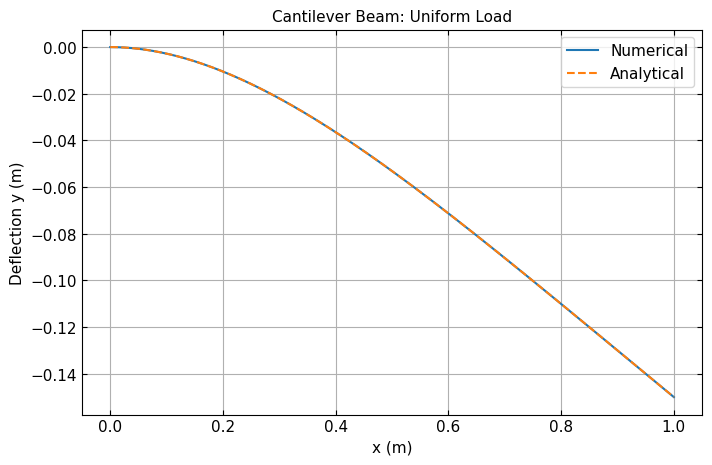

Maximum deflection = -0.14999999999999836 m
Occurs at x = 1.0 m


In [39]:
idx_max = np.argmin(y_uniform_num)
x_max = x[idx_max]
y_max = y_uniform_num[idx_max]

plt.figure(figsize=(8,5))
plt.plot(x, y_uniform_num, label="Numerical")
plt.plot(x, y_uniform_ana, "--", label="Analytical")
plt.xlabel("x (m)")
plt.ylabel("Deflection y (m)")
plt.title("Cantilever Beam: Uniform Load")
plt.legend()
plt.grid(True)
plt.show()

print("Maximum deflection =", y_max, "m")
print("Occurs at x =", x_max, "m")

In [40]:
F = -500.0
sigma = 0.01

x_norm = np.linspace(0, L, 5000)
g = np.exp(-0.5 * ((x_norm - L) / sigma)**2)
area = np.trapezoid(g, x_norm)

def w_point(x):
    return (F / area) * np.exp(-0.5 * ((x - L) / sigma)**2)

In [41]:
sol_point = solve_bvp(
    lambda x, y: beam_ode(x, y, EI, w_point),
    beam_bc,
    x,
    y_guess
)

y_point_num = sol_point.sol(x)[0]

In [42]:
y_point_ana = (F / (6 * EI)) * (3*L*x**2 - x**3)

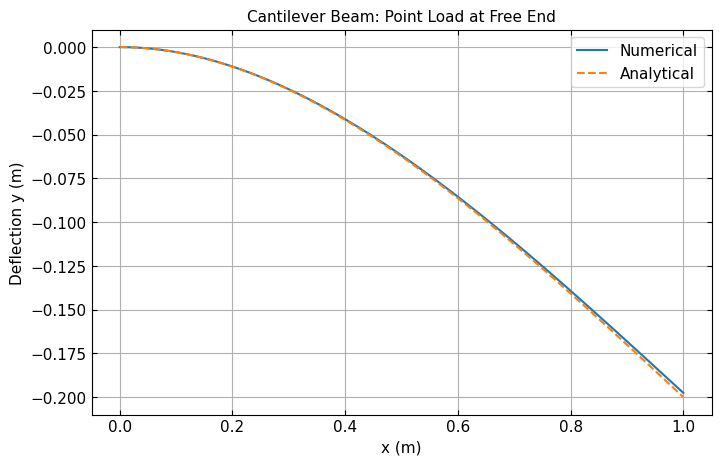

Tip deflection (numerical) = -0.19760649595645413 m
Tip deflection (analytical) = -0.19999999999999996 m


In [43]:
plt.figure(figsize=(8,5))
plt.plot(x, y_point_num, label="Numerical")
plt.plot(x, y_point_ana, "--", label="Analytical")
plt.xlabel("x (m)")
plt.ylabel("Deflection y (m)")
plt.title("Cantilever Beam: Point Load at Free End")
plt.legend()
plt.grid(True)
plt.show()

print("Tip deflection (numerical) =", y_point_num[-1], "m")
print("Tip deflection (analytical) =", y_point_ana[-1], "m")

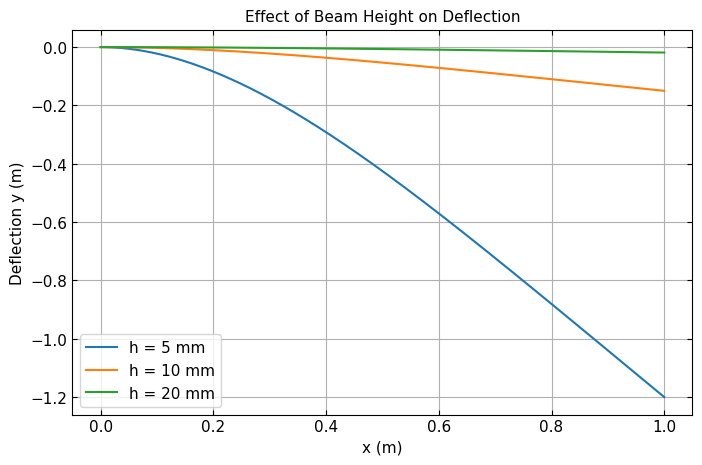

In [44]:
heights_mm = [5, 10, 20]

plt.figure(figsize=(8,5))

for h_mm in heights_mm:
    h_i = h_mm / 1000
    I_i = b * h_i**3 / 12
    EI_i = E * I_i

    sol_i = solve_bvp(
        lambda x, y, EI_i=EI_i: beam_ode(x, y, EI_i, w_uniform),
        beam_bc,
        x,
        y_guess
    )

    y_i = sol_i.sol(x)[0]
    plt.plot(x, y_i, label=f"h = {h_mm} mm")

plt.xlabel("x (m)")
plt.ylabel("Deflection y (m)")
plt.title("Effect of Beam Height on Deflection")
plt.legend()
plt.grid(True)
plt.show()

DeBugging Challenge

/tmp/ipykernel_16963/2825229407.py:47: RuntimeWarning: overflow encountered in scalar add
  u_new[i] = 2*u[i] - u_old[i] + C2 * (u[i+1] + 2*u[i] + u[i-1])  # BUG somewhere here
/tmp/ipykernel_16963/2825229407.py:47: RuntimeWarning: overflow encountered in scalar multiply
  u_new[i] = 2*u[i] - u_old[i] + C2 * (u[i+1] + 2*u[i] + u[i-1])  # BUG somewhere here
/tmp/ipykernel_16963/2825229407.py:47: RuntimeWarning: invalid value encountered in scalar subtract
  u_new[i] = 2*u[i] - u_old[i] + C2 * (u[i+1] + 2*u[i] + u[i-1])  # BUG somewhere here


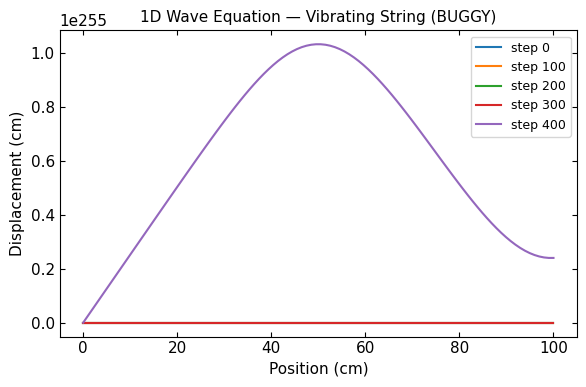

In [47]:
# ============================================================
# DEBUGGING CHALLENGE — BUGGY CODE
# DO NOT FIX THIS CELL — copy it and fix in a new cell below
# ============================================================

def wave_equation_step(
    u: np.ndarray,
    u_old: np.ndarray,
    c: float,
    dx: float,
    dt: float
) -> float:                                              # BUG somewhere in this function
    """Advance the 1D wave equation by one time step.

    Uses the central difference scheme:
    u_new[i] = 2*u[i] - u_old[i] + C^2*(u[i+1] - 2*u[i] + u[i-1])
    where C = c*dt/dx is the Courant number.

    Parameters
    ----------
    u : np.ndarray
        Current displacement profile. Shape (N,).
    u_old : np.ndarray
        Previous displacement profile. Shape (N,).
    c : float
        Wave speed (m/s).
    dx : float
        Spatial grid spacing (m).
    dt : float
        Time step (s).

    Returns
    -------
    np.ndarray
        Next displacement profile. Shape (N,).
    """
    C2 = (c * dt / dx)**2

    # CFL stability check
    if c * dt / dx < 1.0:                                # BUG somewhere near here
        print("Warning: CFL condition violated! Solution may be unstable.")

    u_new = np.zeros_like(u)

    # Interior points: finite difference update
    for i in range(1, len(u) - 1):
        u_new[i] = 2*u[i] - u_old[i] + C2 * (u[i+1] + 2*u[i] + u[i-1])  # BUG somewhere here

    # Boundary conditions: fixed ends
    u_new[0] = 0.0                                       # Left end fixed
    u_new[-1] = u_new[-2]                                # BUG somewhere here

    return u_new


# --- Run the buggy solver ---
L = 1.0         # string length (m)
c = 100.0       # wave speed (m/s)
N = 100         # grid points
dx = L / (N - 1)
dt = 0.8 * dx / c   # Courant number = 0.8

x = np.linspace(0, L, N)

# Initial condition: plucked string (triangle)
u = np.where(x < 0.5, 2*x, 2*(1-x)) * 0.01   # max displacement 1 cm
u_old = u.copy()  # start from rest (first-order approximation)

# Time stepping
fig, ax = plt.subplots()
n_steps = 500
for step in range(n_steps):
    u_new = wave_equation_step(u, u_old, c, dx, dt)
    u_old = u
    u = u_new
    if step % 100 == 0:
        ax.plot(x * 100, u * 100, label=f'step {step}')

ax.set_xlabel('Position (cm)')
ax.set_ylabel('Displacement (cm)')
ax.set_title('1D Wave Equation — Vibrating String (BUGGY)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

4 Bugs:
1. Should be np.ndarry instead of float
2. The CFL should be (c * dt / dx > 1.0)
3. Finite difference should be (u[i+1] - 2*u[i] + u[i-1])
4. The boundray should be set to 0


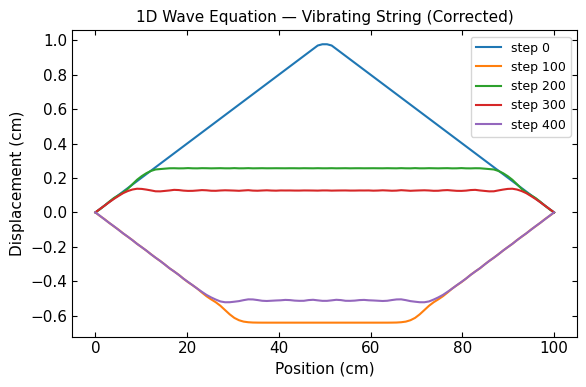

In [46]:
# ============================================================
# DEBUGGED VERSION
# ============================================================

def wave_equation_step(
    u: np.ndarray,
    u_old: np.ndarray,
    c: float,
    dx: float,
    dt: float
) -> np.ndarray:
    """Advance the 1D wave equation by one time step.

    Uses the central difference scheme:
    u_new[i] = 2*u[i] - u_old[i] + C^2*(u[i+1] - 2*u[i] + u[i-1])
    where C = c*dt/dx is the Courant number.
    """
    C2 = (c * dt / dx)**2

    # CFL stability check
    if c * dt / dx > 1.0:
        print("Warning: CFL condition violated! Solution may be unstable.")

    u_new = np.zeros_like(u)

    # Interior points
    for i in range(1, len(u) - 1):
        u_new[i] = 2*u[i] - u_old[i] + C2 * (u[i+1] - 2*u[i] + u[i-1])

    # Fixed-end boundary conditions
    u_new[0] = 0.0
    u_new[-1] = 0.0

    return u_new


# --- Run the corrected solver ---
L = 1.0
c = 100.0
N = 100
dx = L / (N - 1)
dt = 0.8 * dx / c   # Courant number = 0.8

x = np.linspace(0, L, N)

# Initial condition: plucked string
u = np.where(x < 0.5, 2*x, 2*(1-x)) * 0.01
u_old = u.copy()

# Time stepping
fig, ax = plt.subplots()
n_steps = 500
for step in range(n_steps):
    u_new = wave_equation_step(u, u_old, c, dx, dt)
    u_old = u
    u = u_new
    if step % 100 == 0:
        ax.plot(x * 100, u * 100, label=f"step {step}")

ax.set_xlabel("Position (cm)")
ax.set_ylabel("Displacement (cm)")
ax.set_title("1D Wave Equation — Vibrating String")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()